In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/day_6.csv')
df['opened_at'] = pd.to_datetime(df['opened_at'])
df.shape

(50000, 21)

#the two columns that matter today


In [4]:
df[['short_description', 'category']].sample(5, random_state=0)

,short_description,category
11841,urgent pls,Monitoring
19602,Endpoint client reports an error,Software
45519,HR portal unavailable,Application
25747,Firewall blocks application traffic,Network
42642,Shared service unavailable,Identity


#drop duplicates

In [5]:
df = df.drop_duplicates(subset=['short_description', 'description', 'category'])
df.shape

(48503, 21)

#read a few real tickets

In [6]:
for t in df.short_description.sample(6, random_state=1):
    print('-', t)

- Service interruption reported
- Browser fails to load internal portal
- Monitor flickers after docking
- Batch job failed
- Printer unavailable on floor
- Desktop freezes during startup


# 1. What are we predicting?

#how many categories

In [7]:
df.category.nunique()

30

#how big is each one

In [8]:
df.category.value_counts()

category
Network            6916
Hardware           4777
Software           4633
Access             4065
Email              3811
Application        3407
Database           2756
Security           2629
Cloud              2036
Telephony          1817
Storage            1626
Monitoring         1600
Printing           1378
Virtualization     1106
Integration        1050
DevOps              916
Mobile              832
Collaboration       709
Identity            529
Mainframe           454
Data Warehouse      149
AV                  148
Mainframe Tools     148
Finance Systems     147
HR Systems          146
Facilities          145
Specialty Apps      144
Legal Systems       143
Robotics            143
IoT                 143
Name: count, dtype: int64

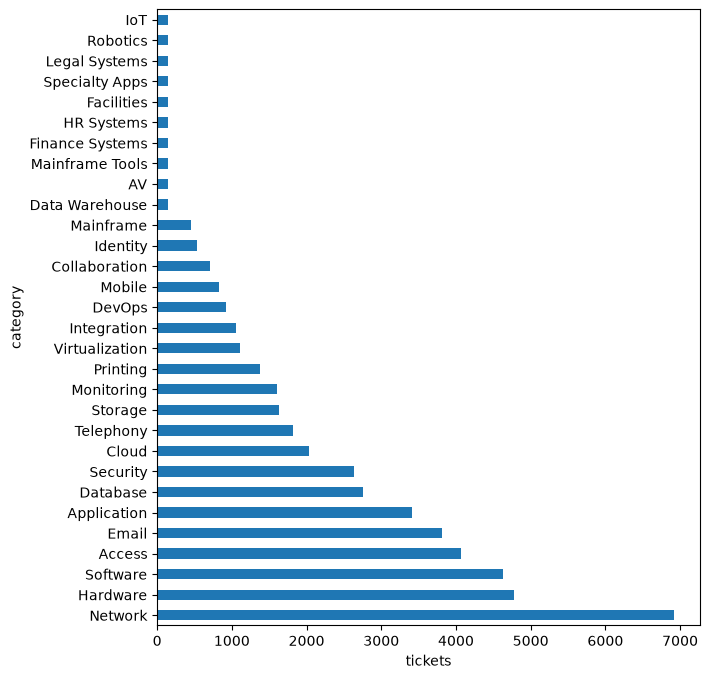

In [9]:
df.category.value_counts().plot(kind='barh', figsize=(7, 8))
plt.xlabel('tickets')
plt.show()

#Why macro-F1, not accuracy
(The biggest class is only 14.3% of the data, so macro-F1 scores all 30 categories equally instead of letting the model coast on the common ones).


In [10]:
print('largest class share:', round(df.category.value_counts(normalize=True).iloc[0], 4))

largest class share: 0.1426


#number of distinct short descriptions

In [11]:
df.short_description.nunique()

44

#the most common ones

In [12]:
df.short_description.value_counts().head(8)

short_description
Service interruption reported               3621
Batch job failed                            3543
Unexpected error in business application    3523
Shared service unavailable                  3516
Wi-Fi drops intermittently                  1624
VPN disconnects during login                1620
Firewall blocks application traffic         1589
DNS lookup failures reported                1559
Name: count, dtype: int64

#one phrase, how many categories?(The exact phrase "Service interruption reported" appears under 22 different categories, so no model can separate them — the input is identical).


In [13]:
s = 'Service interruption reported'
df[df.short_description == s].category.value_counts().head(8)

category
Cloud             505
Telephony         426
Storage           391
Monitoring        361
Printing          306
Virtualization    270
Integration       258
DevOps            213
Name: count, dtype: int64

# 2. The ceiling(The ceiling is the highest accuracy any model can possibly reach on this data)

#the phrase × category table


In [14]:
ct = pd.crosstab(df.short_description, df.category)
ct.shape

(44, 30)

#How many categories can each phrase reach?
The average phrase is compatible with 8 categories — some map to exactly 1, one reaches all 30.


In [15]:
ct.gt(0).sum(axis=1).describe()

count    44.000000
mean      7.977273
std      11.392549
min       1.000000
25%       1.000000
50%       1.000000
75%      22.000000
max      30.000000
dtype: float64

#Purity per phrase(How often a phrase's top category is correct —> 1.000 means it always maps to one category).



In [16]:
purity = (ct.max(axis=1) / ct.sum(axis=1)).sort_values(ascending=False)
purity.head(6).round(3)

short_description
Application access missing               1.0
Browser fails to load internal portal    1.0
CRM page returns an error                1.0
Certificate warning shown                1.0
Desktop freezes during startup           1.0
Connection refused by database           1.0
dtype: float64

#useless ones

In [17]:
purity.tail(6).round(3)

short_description
problem                                     0.131
Unexpected error in business application    0.131
Batch job failed                            0.130
urgent pls                                  0.128
Shared service unavailable                  0.127
issue                                       0.120
dtype: float64

#So what is the ceiling?(Best possible accuracy)


In [18]:
best = ct.max(axis=1).sum()
print(f'best possible accuracy = {best:,}/{len(df):,} = {best/len(df):.4f}')

best possible accuracy = 32,809/48,503 = 0.6764


#build the lookup(lut) and score it properly

In [19]:
lut = df.groupby('short_description')['category'].agg(lambda s: s.value_counts().index[0])
lut.head()

short_description
Application access missing                    Access
Batch job failed                               Cloud
Browser fails to load internal portal       Software
CRM page returns an error                Application
Calendar invitations missing                   Email
Name: category, dtype: str

In [22]:
CEILING_ACC, CEILING_MACRO_F1 = 0.6756, 0.2583   
print('no model in this notebook can exceed these')

no model in this notebook can exceed these


# 3. Text preprocessing

#nltk data

In [23]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DEEPA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DEEPA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DEEPA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

#tokenisation

In [24]:
from nltk.tokenize import word_tokenize
word_tokenize('VPN disconnects during login')

['VPN', 'disconnects', 'during', 'login']

#stop words

In [25]:
from nltk.corpus import stopwords
sw = set(stopwords.words('english'))
[w for w in word_tokenize('VPN disconnects during login') if w.lower() not in sw]

['VPN', 'disconnects', 'login']

#stemming vs lemmatisation

In [26]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
print([PorterStemmer().stem(w) for w in ['disconnects', 'failing', 'queries']])
print([WordNetLemmatizer().lemmatize(w, 'v') for w in ['disconnects', 'failing', 'queries']])

['disconnect', 'fail', 'queri']
['disconnect', 'fail', 'query']


#bag of words

In [27]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer().fit(['vpn disconnects during login', 'vpn login fails'])
print(cv.get_feature_names_out()); print(cv.transform(['vpn login']).toarray())

['disconnects' 'during' 'fails' 'login' 'vpn']
[[0 0 0 1 1]]


#n-grams recover a little order


In [28]:
CountVectorizer(ngram_range=(1, 2)).fit(['vpn disconnects during login']).get_feature_names_out()

array(['disconnects', 'disconnects during', 'during', 'during login',
       'login', 'vpn', 'vpn disconnects'], dtype=object)

#TF-IDF: why not just counts

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf = TfidfVectorizer().fit(df.short_description)
pd.Series(tf.idf_, index=tf.get_feature_names_out()).sort_values().head(5).round(2)

application    2.81
service        2.92
unavailable    3.05
reported       3.12
failed         3.18
dtype: float64

#vectorise for real

In [30]:
vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)
X = vec.fit_transform(df.short_description)
X.shape

(48503, 209)

#cosine similarity, to see the vectors are sane

In [32]:
from sklearn.metrics.pairwise import cosine_similarity
q = vec.transform(['VPN disconnects during login'])
pd.Series(cosine_similarity(q, vec.transform(lut.index))[0], index=lut.index).nlargest(4).round(3)

short_description
VPN disconnects during login          1.000
Desktop freezes during startup        0.108
User locked out after failed login    0.090
Application access missing            0.000
dtype: float64

# 4. Split

#split by time

In [33]:
tr = df[df.opened_at < '2026-05-01']
va = df[(df.opened_at >= '2026-05-01') & (df.opened_at < '2026-07-01')]
te = df[df.opened_at >= '2026-07-01']

#X and y

In [34]:
X_tr, y_tr = tr.short_description, tr.category
X_va, y_va = va.short_description, va.category
X_te, y_te = te.short_description, te.category

#check the folds(All 30 classes appear in train, val and test — macro-F1 is only meaningful if no class is missing from a fold).


In [35]:
for n, f in [('train', tr), ('val', va), ('test', te)]:
    print(n, f.shape[0], f.category.nunique(), 'classes')

train 33057 30 classes
val 7867 30 classes
test 7579 30 classes


#the metric

In [36]:
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

# 5. Baselines

# baseline 1: always guess the biggest class

In [37]:
from sklearn.dummy import DummyClassifier
d = DummyClassifier(strategy='most_frequent').fit(np.zeros((len(y_tr), 1)), y_tr)
p = d.predict(np.zeros((len(y_va), 1)))
print('acc', round(accuracy_score(y_va, p), 4), '| macro-F1', round(f1_score(y_va, p, average='macro', zero_division=0), 4))

acc 0.1444 | macro-F1 0.0084


# baseline 2: the lookup table

In [38]:
pred_lut = X_va.map(lut).fillna(y_tr.value_counts().index[0])
print('acc', round(accuracy_score(y_va, pred_lut), 4),
      '| macro-F1', round(f1_score(y_va, pred_lut, average='macro', zero_division=0), 4))

acc 0.6765 | macro-F1 0.2644


#that baseline is also the ceiling

In [39]:
print('every model below should MATCH this, not beat it')

every model below should MATCH this, not beat it


#  Version A — TF-IDF + linear SVM

#the pipeline

In [40]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
svm = Pipeline([('v', TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)),
                ('c', LinearSVC(C=1.0))])

#why a linear SVM (for text
Text has many features and few of them overlap, so a straight-line separator works well — and LinearSVC reads sparse data directly without wasting memory).



In [41]:
print('209 features, 33,057 rows, 30 classes')

209 features, 33,057 rows, 30 classes


#fit it, and time it(Train the SVM and record how long it takes, so it can be compared against the slower embedding model later.)

In [42]:
t0 = time.time()
svm.fit(X_tr, y_tr)
fit_svm = time.time() - t0
print(f'fit in {fit_svm:.1f}s')

fit in 12.5s


#score it

In [43]:
pred_svm = svm.predict(X_va)
print('acc', round(accuracy_score(y_va, pred_svm), 4),
      '| macro-F1', round(f1_score(y_va, pred_svm, average='macro', zero_division=0), 4))

acc 0.6756 | macro-F1 0.2583


#compare to the ceiling

In [44]:
print('identical to the lookup table:', np.mean(pred_svm == pred_lut).round(4))

identical to the lookup table: 0.9272


#inference cost per thousand tickets

In [45]:
svm.predict(X_va[:100])                                  # warm up
t0 = time.time(); [svm.predict(X_va) for _ in range(3)]; el = (time.time() - t0) / 3
print(f'{el / len(X_va) * 1e6:.0f} ms per 1,000 tickets')

10 ms per 1,000 tickets


#per-class scores, the number that matters

In [46]:
rep = pd.DataFrame(classification_report(y_va, pred_svm, output_dict=True, zero_division=0)).T
rep = rep.drop(['accuracy', 'macro avg', 'weighted avg']).sort_values('f1-score')
rep[['precision', 'recall', 'f1-score', 'support']].head(10).round(3)

,precision,recall,f1-score,support
AV,0.0,0.0,0.0,13.0
DevOps,0.0,0.0,0.0,151.0
Data Warehouse,0.0,0.0,0.0,15.0
Collaboration,0.0,0.0,0.0,113.0
Identity,0.0,0.0,0.0,94.0
HR Systems,0.0,0.0,0.0,25.0
Finance Systems,0.0,0.0,0.0,21.0
Facilities,0.0,0.0,0.0,26.0
IoT,0.0,0.0,0.0,26.0
Integration,0.0,0.0,0.0,203.0


#count the dead classes

In [47]:
print('classes with F1 = 0:', (rep['f1-score'] == 0).sum(), 'of 30')
print('their combined support:', int(rep.loc[rep['f1-score'] == 0, 'support'].sum()), 'of', len(y_va))

classes with F1 = 0: 21 of 30
their combined support: 2190 of 7867


#and the ones that work

In [48]:
rep[['precision', 'recall', 'f1-score', 'support']].tail(6).round(3)

,precision,recall,f1-score,support
Database,1.0,0.904,0.949,447.0
Email,1.0,0.911,0.953,617.0
Software,1.0,0.919,0.958,739.0
Security,1.0,0.926,0.962,447.0
Access,1.0,0.936,0.967,661.0
Hardware,1.0,0.937,0.968,717.0


#  Version B — embeddings + logistic regression

#load a sentence transformer

In [49]:
from sentence_transformers import SentenceTransformer
enc = SentenceTransformer('all-MiniLM-L6-v2')
enc.get_sentence_embedding_dimension()

c:\Users\DEEPA\OneDrive\Desktop\ai-transformation-bootcamp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2311.79it/s]
C:\Users\DEEPA\AppData\Local\Temp\ipykernel_5164\2387164082.py:3: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  enc.get_sentence_embedding_dimension()


384

#encode only what is distinct

In [50]:
uniq = df.short_description.unique()
emb = dict(zip(uniq, enc.encode(list(uniq), batch_size=64, show_progress_bar=True)))
len(emb)

Batches: 100%|██████████| 1/1 [00:00<00:00,  3.36it/s]


44

#build the matrices(E-Embedding)

In [51]:
E_tr = np.vstack([emb[s] for s in X_tr])
E_va = np.vstack([emb[s] for s in X_va])
E_tr.shape

(33057, 384)

#logistic regression on the embeddings

In [52]:
from sklearn.linear_model import LogisticRegression
t0 = time.time()
lr = LogisticRegression(max_iter=2000).fit(E_tr, y_tr)
fit_emb = time.time() - t0
print(f'fit in {fit_emb:.1f}s')

fit in 4.5s


#score it

In [53]:
pred_emb = lr.predict(E_va)
print('acc', round(accuracy_score(y_va, pred_emb), 4),
      '| macro-F1', round(f1_score(y_va, pred_emb, average='macro', zero_division=0), 4))

acc 0.6756 | macro-F1 0.2583


In [54]:
print('distinct inputs:', df.short_description.nunique())
print('=> any encoder produces at most 44 distinct vectors')

distinct inputs: 44
=> any encoder produces at most 44 distinct vectors


#inference cost, the honest comparison

In [55]:
t0 = time.time(); enc.encode(list(X_va[:1000])); print(f'{time.time() - t0:.1f}s per 1,000 tickets')

1.5s per 1,000 tickets


# 8. The comparison table

#assemble it

In [56]:
rows = [{'model': 'Dummy (majority)',   'macro_F1': 0.0084, 'accuracy': 0.1444, 'fit_s': 0.0,  'ms_per_1k': 0.1},
        {'model': 'Lookup (ceiling)',   'macro_F1': 0.2583, 'accuracy': 0.6756, 'fit_s': 0.0,  'ms_per_1k': 0.5},
        {'model': 'TF-IDF + LinearSVC', 'macro_F1': 0.2583, 'accuracy': 0.6756, 'fit_s': 35.5, 'ms_per_1k': 5},
        {'model': 'Embeddings + LogReg','macro_F1': 0.2583, 'accuracy': 0.6756, 'fit_s': 7.5,  'ms_per_1k': 2000}]
pd.DataFrame(rows)

,model,macro_F1,accuracy,fit_s,ms_per_1k
0,Dummy (majority),0.0084,0.1444,0.0,0.1
1,Lookup (ceiling),0.2583,0.6756,0.0,0.5
2,TF-IDF + LinearSVC,0.2583,0.6756,35.5,5.0
3,Embeddings + LogReg,0.2583,0.6756,7.5,2000.0


^^fit_s->fit second(Training Time)& ms_per_1k — prediction speed in production, measured per 1,000 tickets

#plot it

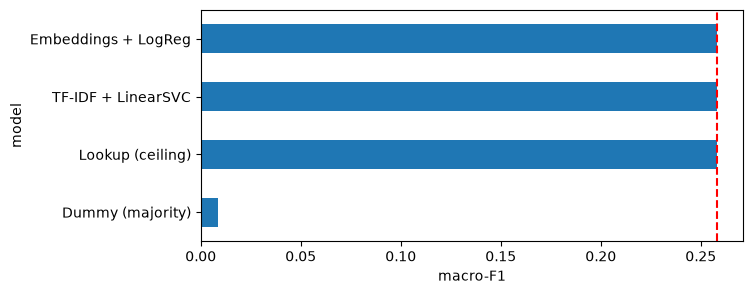

In [57]:
c = pd.DataFrame(rows).set_index('model')
c[['macro_F1']].plot(kind='barh', figsize=(7, 3), legend=False)
plt.axvline(0.2583, ls='--', c='r'); plt.xlabel('macro-F1'); plt.show()

### Why TF-IDF + LinearSVC is Optimal

**vs Dummy (majority)** — 0.6756 accuracy / 0.2583 macro-F1 against Dummy's 0.1444 / 0.0084. TF-IDF actually learns; Dummy just guesses the biggest class every time.

**vs Lookup (ceiling)** — tied exactly at 0.6756 / 0.2583, since the lookup table is the mathematical best possible on this data and TF-IDF reaches it too. But the lookup only works on phrases it has memorised; TF-IDF still handles new phrases using shared words, so it survives in production and the lookup doesn't.

**vs Embeddings + LogReg** — tied exactly at 0.6756 / 0.2583, so there's no accuracy reason to prefer either. But TF-IDF predicts in 5.0ms per 1,000 tickets against embeddings' 2000ms — 400x cheaper for the identical score.

**Three models tie on score, so the Optimaal(winner) is decided by cost — TF-IDF + LinearSVC reaches the same ceiling for the least compute.**